# Late-fusion experiment: STAGATE + SpaGCN

The two best-performing spatial encoders are combined by **concatenating their embeddings**
(late / feature-level fusion); the fused representation is then clustered and compared against
each encoder alone. This uses the cached `.npy` embeddings, so no TensorFlow/encoders are run here.

Clustering heads: KMeans (given ground-truth k) and ClusterPFN (5D model, given k).


In [ ]:
import numpy as np
import pandas as pd
import scanpy as sc
import torch
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

import clusterpfn.transformer as transformer

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")

SECTIONS = [
    "151507", "151508", "151509", "151510",
    "151669", "151670", "151671", "151672",
    "151673", "151674", "151675", "151676",
]

EMB_DIR = "experiment_c_embeddings"
FUSE_METHODS = ["STAGATE", "SpaGCN"]   # the two best encoders

PFN_MODEL_PATH = "models/pfn_hard_5D.pt"
PFN_IN_FEATURES = 5
PFN_BUCKETS = 10

RESULTS_FILE = "results/fusion_results.csv"


## Helper functions

Everything the sweep needs: load a cached embedding / ground truth, `fuse` (standardize each encoder
then concatenate, which *is* the late-fusion step), the three clustering heads (KMeans, resolution-searched
Louvain, and ClusterPFN), and the PFN input adapter (`StandardScaler`, PCA to 5D, then `MinMaxScaler`).


In [2]:
def load_embedding(method, sec):
    return np.load(f"{EMB_DIR}/{sec}_{method}_embedding.npy")


def load_ground_truth(sec):
    adata = sc.read_h5ad(f"data/DLPFC_{sec}_ST_final.h5ad")
    gt = adata.obs["Ground Truth"].astype(str)
    return gt, gt.nunique()


def fuse(embeddings):
    """Standardize each embedding independently, then concatenate (late fusion)."""
    parts = [StandardScaler().fit_transform(np.asarray(e)) for e in embeddings]
    return np.concatenate(parts, axis=1)


def evaluate(gt, pred):
    return adjusted_rand_score(gt, pred), normalized_mutual_info_score(gt, pred)


def cluster_kmeans(X, k, seed=42):
    Xs = StandardScaler().fit_transform(np.asarray(X))
    return KMeans(n_clusters=k, random_state=seed, n_init=20).fit_predict(Xs)


def cluster_louvain(X, k, seed=42, n_neighbors=15, max_iter=25):
    """Louvain on a kNN graph; binary-search the resolution to hit k communities."""
    ad = sc.AnnData(StandardScaler().fit_transform(np.asarray(X)).astype(np.float32))
    sc.pp.neighbors(ad, n_neighbors=n_neighbors, use_rep="X", random_state=seed)
    lo, hi, best = 0.1, 3.0, None
    for _ in range(max_iter):
        res = (lo + hi) / 2
        sc.tl.louvain(ad, resolution=res, random_state=seed)
        labels = ad.obs["louvain"].astype(int).to_numpy()
        found = len(np.unique(labels))
        if found == k:
            return labels
        best = labels
        if found < k:
            lo = res
        else:
            hi = res
    return best


def prepare_for_pfn(X, in_features=PFN_IN_FEATURES):
    Xs = StandardScaler().fit_transform(np.asarray(X))
    if Xs.shape[1] > in_features:
        Xs = PCA(n_components=in_features, random_state=42).fit_transform(Xs)
    Xs = MinMaxScaler().fit_transform(Xs)
    return Xs.astype(np.float32)


def load_pfn():
    model = transformer.Transformer(256, 4, 512, 4,
                                    in_features=PFN_IN_FEATURES, buckets_size=PFN_BUCKETS).to(device)
    ck = torch.load(PFN_MODEL_PATH, map_location=device)
    model.load_state_dict(ck["model_state_dict"])
    model.eval()
    return model


def run_pfn(model, X, k):
    t = torch.tensor(X, dtype=torch.float32, device=device).unsqueeze(1)  # (S, 1, F)
    num = torch.full((t.shape[0] + 1, 1), int(k), dtype=torch.long, device=device)
    with torch.no_grad():
        out, _ = model(t, num)
    return out.squeeze(1).argmax(dim=-1).cpu().numpy()


## Run the fusion sweep

For every section, STAGATE alone, SpaGCN alone, and their fused representation are each scored with all
three clustering heads, and the ARI/NMI values are collected into one table written to
`results/fusion_results.csv`.


In [3]:
pfn = load_pfn()

rows = []
for sec in SECTIONS:
    gt, k = load_ground_truth(sec)

    embeddings = {m: load_embedding(m, sec) for m in FUSE_METHODS}
    embeddings["Fused"] = fuse([embeddings[m] for m in FUSE_METHODS])

    row = {"section": sec, "n_clusters": k}
    for name, emb in embeddings.items():
        km_ari, km_nmi = evaluate(gt, cluster_kmeans(emb, k))
        lou_ari, lou_nmi = evaluate(gt, cluster_louvain(emb, k))
        pfn_pred = run_pfn(pfn, prepare_for_pfn(emb), k)
        pfn_ari, pfn_nmi = evaluate(gt, pfn_pred)

        row[f"{name}_KMeans_ARI"] = km_ari
        row[f"{name}_KMeans_NMI"] = km_nmi
        row[f"{name}_Louvain_ARI"] = lou_ari
        row[f"{name}_Louvain_NMI"] = lou_nmi
        row[f"{name}_PFN_ARI"] = pfn_ari
        row[f"{name}_PFN_NMI"] = pfn_nmi

    rows.append(row)
    print(sec,
          "| Fused KMeans ARI", round(row["Fused_KMeans_ARI"], 3),
          "| Fused Louvain ARI", round(row["Fused_Louvain_ARI"], 3),
          "| Fused PFN ARI", round(row["Fused_PFN_ARI"], 3))

df = pd.DataFrame(rows)
df.to_csv(RESULTS_FILE, index=False)
df.round(3)


/Users/muradyan.e/wut/bioinform/.venv/lib/python3.11/site-packages/torch/nn/modules/transformer.py:144: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.encoder = TransformerEncoder(
/Users/muradyan.e/wut/bioinform/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


151507 | Fused KMeans ARI 0.439 | Fused Louvain ARI 0.565 | Fused PFN ARI 0.327
151508 | Fused KMeans ARI 0.306 | Fused Louvain ARI 0.428 | Fused PFN ARI 0.289
151509 | Fused KMeans ARI 0.429 | Fused Louvain ARI 0.489 | Fused PFN ARI 0.301
151510 | Fused KMeans ARI 0.268 | Fused Louvain ARI 0.372 | Fused PFN ARI 0.378
151669 | Fused KMeans ARI 0.387 | Fused Louvain ARI 0.418 | Fused PFN ARI 0.373
151670 | Fused KMeans ARI 0.203 | Fused Louvain ARI 0.355 | Fused PFN ARI 0.354
151671 | Fused KMeans ARI 0.493 | Fused Louvain ARI 0.543 | Fused PFN ARI 0.238
151672 | Fused KMeans ARI 0.759 | Fused Louvain ARI 0.687 | Fused PFN ARI 0.643
151673 | Fused KMeans ARI 0.47 | Fused Louvain ARI 0.413 | Fused PFN ARI 0.456
151674 | Fused KMeans ARI 0.52 | Fused Louvain ARI 0.44 | Fused PFN ARI 0.147
151675 | Fused KMeans ARI 0.393 | Fused Louvain ARI 0.514 | Fused PFN ARI 0.308
151676 | Fused KMeans ARI 0.266 | Fused Louvain ARI 0.397 | Fused PFN ARI 0.158


,section,n_clusters,STAGATE_KMeans_ARI,STAGATE_KMeans_NMI,STAGATE_Louvain_ARI,STAGATE_Louvain_NMI,STAGATE_PFN_ARI,STAGATE_PFN_NMI,SpaGCN_KMeans_ARI,SpaGCN_KMeans_NMI,SpaGCN_Louvain_ARI,SpaGCN_Louvain_NMI,SpaGCN_PFN_ARI,SpaGCN_PFN_NMI,Fused_KMeans_ARI,Fused_KMeans_NMI,Fused_Louvain_ARI,Fused_Louvain_NMI,Fused_PFN_ARI,Fused_PFN_NMI
0,151507,7,0.429,0.577,0.476,0.618,0.450,0.537,0.424,0.553,0.410,0.520,0.384,0.469,0.439,0.583,0.565,0.624,0.327,0.473
1,151508,7,0.482,0.574,0.443,0.571,0.374,0.480,0.278,0.419,0.322,0.411,0.288,0.377,0.306,0.471,0.428,0.535,0.289,0.465
2,151509,7,0.448,0.576,0.528,0.619,0.392,0.458,0.384,0.569,0.355,0.552,0.423,0.460,0.429,0.609,0.489,0.623,0.301,0.459
3,151510,7,0.258,0.456,0.372,0.516,0.297,0.428,0.268,0.448,0.353,0.427,0.344,0.424,0.268,0.459,0.372,0.531,0.378,0.460
4,151669,5,0.337,0.458,0.340,0.475,-0.036,0.222,0.347,0.561,0.363,0.565,0.538,0.529,0.387,0.553,0.418,0.583,0.373,0.553
5,151670,5,0.209,0.396,0.301,0.450,0.268,0.355,0.203,0.385,0.208,0.406,0.237,0.315,0.203,0.400,0.355,0.450,0.354,0.343
6,151671,5,0.295,0.449,0.411,0.567,0.146,0.307,0.494,0.561,0.356,0.545,0.149,0.356,0.493,0.564,0.543,0.612,0.238,0.407
7,151672,5,0.485,0.560,0.686,0.668,0.608,0.598,0.755,0.702,0.652,0.656,0.688,0.643,0.759,0.712,0.687,0.673,0.643,0.601
8,151673,7,0.414,0.557,0.394,0.539,0.205,0.341,0.449,0.548,0.405,0.537,0.460,0.522,0.470,0.573,0.413,0.579,0.456,0.563
9,151674,7,0.284,0.462,0.442,0.535,0.305,0.384,0.496,0.599,0.468,0.592,0.370,0.411,0.520,0.617,0.440,0.588,0.147,0.312


## Does fusion beat the single encoders?

Every metric averaged across the 12 sections shows whether the fused representation improves on STAGATE
and SpaGCN alone, for each clustering head.


In [4]:
# Mean scores per encoder/head — does fusion beat the single encoders?
summary = pd.DataFrame({
    "mean_ARI": {c.replace("_ARI", ""): df[c].mean() for c in df.columns if c.endswith("_ARI")},
    "mean_NMI": {c.replace("_NMI", ""): df[c].mean() for c in df.columns if c.endswith("_NMI")},
}).round(3)

print(summary.to_string())
summary


                 mean_ARI  mean_NMI
STAGATE_KMeans      0.364     0.508
STAGATE_Louvain     0.442     0.562
STAGATE_PFN         0.305     0.421
SpaGCN_KMeans       0.386     0.512
SpaGCN_Louvain      0.378     0.501
SpaGCN_PFN          0.363     0.430
Fused_KMeans        0.411     0.540
Fused_Louvain       0.468     0.579
Fused_PFN           0.331     0.448


,mean_ARI,mean_NMI
STAGATE_KMeans,0.364,0.508
STAGATE_Louvain,0.442,0.562
STAGATE_PFN,0.305,0.421
SpaGCN_KMeans,0.386,0.512
SpaGCN_Louvain,0.378,0.501
SpaGCN_PFN,0.363,0.430
Fused_KMeans,0.411,0.540
Fused_Louvain,0.468,0.579
Fused_PFN,0.331,0.448


## Per-section ARI table (LaTeX export)

Mean ± std per method and head, together with a per-section ARI table written to
`results/fusion_persection_table.tex` for direct inclusion in the write-up.


In [ ]:
# Mean +/- std per method, and a per-section LaTeX table (ARI)
methods = ["STAGATE", "SpaGCN", "Fused"]
heads = ["KMeans", "Louvain", "PFN"]

print("mean +/- std (ARI / NMI):")
for h in heads:
    for m in methods:
        a, n = df[f"{m}_{h}_ARI"], df[f"{m}_{h}_NMI"]
        print(f"  {m:8s} {h:7s} | ARI {a.mean():.3f} +/- {a.std():.3f} "
              f"| NMI {n.mean():.3f} +/- {n.std():.3f}")

# Per-section ARI LaTeX table (single encoders vs fused, all heads).
ari_cols = [f"{m}_{h}_ARI" for h in heads for m in methods]
tex = df.set_index("section")[ari_cols].round(3)
mean_row = tex.mean().round(3)

header = " & ".join(f"{m}-{h}" for h in heads for m in methods)
lines = [
    "\\begin{table}[htbp]", "  \\centering",
    "  \\caption{Per-section ARI for single encoders and their late fusion.}",
    "  \\label{tab:fusion-persection}",
    "  \\begin{tabular}{l" + "c" * len(ari_cols) + "}",
    "    \\toprule",
    f"    Section & {header} \\\\",
    "    \\midrule",
]
for sec, r in tex.iterrows():
    lines.append("    " + sec + " & " + " & ".join(f"{v:.3f}" for v in r) + " \\\\")
lines += [
    "    \\midrule",
    "    Mean & " + " & ".join(f"{v:.3f}" for v in mean_row) + " \\\\",
    "    \\bottomrule", "  \\end{tabular}", "\\end{table}",
]
latex_table = "\n".join(lines)
print("\n" + latex_table)

with open("results/fusion_persection_table.tex", "w") as f:
    f.write(latex_table)
print("\nSaved -> results/fusion_persection_table.tex")


mean +/- std (ARI / NMI):
  STAGATE  KMeans  | ARI 0.364 +/- 0.090 | NMI 0.508 +/- 0.062
  SpaGCN   KMeans  | ARI 0.386 +/- 0.158 | NMI 0.512 +/- 0.107
  Fused    KMeans  | ARI 0.411 +/- 0.148 | NMI 0.540 +/- 0.091
  STAGATE  Louvain | ARI 0.442 +/- 0.103 | NMI 0.562 +/- 0.063
  SpaGCN   Louvain | ARI 0.378 +/- 0.113 | NMI 0.501 +/- 0.095
  Fused    Louvain | ARI 0.468 +/- 0.095 | NMI 0.579 +/- 0.060
  STAGATE  PFN     | ARI 0.305 +/- 0.159 | NMI 0.421 +/- 0.104
  SpaGCN   PFN     | ARI 0.363 +/- 0.164 | NMI 0.430 +/- 0.116
  Fused    PFN     | ARI 0.331 +/- 0.133 | NMI 0.448 +/- 0.098

\begin{table}[htbp]
  \centering
  \caption{Per-section ARI for single encoders and their late fusion.}
  \label{tab:fusion-persection}
  \begin{tabular}{lccccccccc}
    \toprule
    Section & STAGATE-KMeans & SpaGCN-KMeans & Fused-KMeans & STAGATE-Louvain & SpaGCN-Louvain & Fused-Louvain & STAGATE-PFN & SpaGCN-PFN & Fused-PFN \\
    \midrule
    151507 & 0.429 & 0.424 & 0.439 & 0.476 & 0.410 & 0.565 & 

## Bar chart: single encoders vs fusion

Mean ARI with std error bars for STAGATE, SpaGCN, and the fused representation, grouped by clustering head.
Saved to `figures/fusion_barplot.png`.


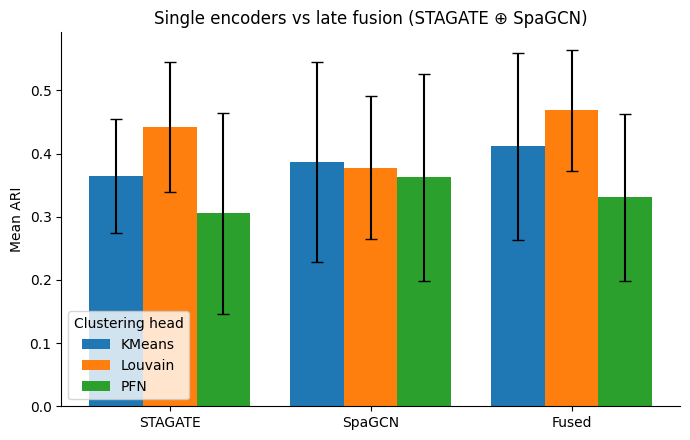

Saved -> fusion_barplot.png


In [ ]:
# Bar chart: single encoders vs fused (mean ARI, std error bars), per head
import matplotlib.pyplot as plt

x = np.arange(len(methods))
width = 0.8 / len(heads)
fig, ax = plt.subplots(figsize=(7, 4.5))

for i, h in enumerate(heads):
    means = [df[f"{m}_{h}_ARI"].mean() for m in methods]
    stds = [df[f"{m}_{h}_ARI"].std() for m in methods]
    offset = (i - (len(heads) - 1) / 2) * width
    ax.bar(x + offset, means, width, yerr=stds, capsize=4, label=h)

pair_label = " \u2295 ".join(FUSE_METHODS)
ax.set_xticks(x)
ax.set_xticklabels(methods)
ax.set_ylabel("Mean ARI")
ax.set_title(f"Single encoders vs late fusion ({pair_label})")
ax.legend(title="Clustering head")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("figures/fusion_barplot.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved -> figures/fusion_barplot.png")


## Spatial maps of predicted domains

Qualitative view for one section (`151672`): predicted spatial domains for every embedding and clustering
head, next to the ground truth. Produces the pipeline grid and the fusion grid in `experiment_c_plots/`.


Embeddings pipeline...
  STAGATE+KMeans ...
  STAGATE+Louvain ...
  STAGATE+PFN ...
  GraphST+KMeans ...
  GraphST+Louvain ...
  GraphST+PFN ...
  SpaGCN+KMeans ...
  SpaGCN+Louvain ...
  SpaGCN+PFN ...


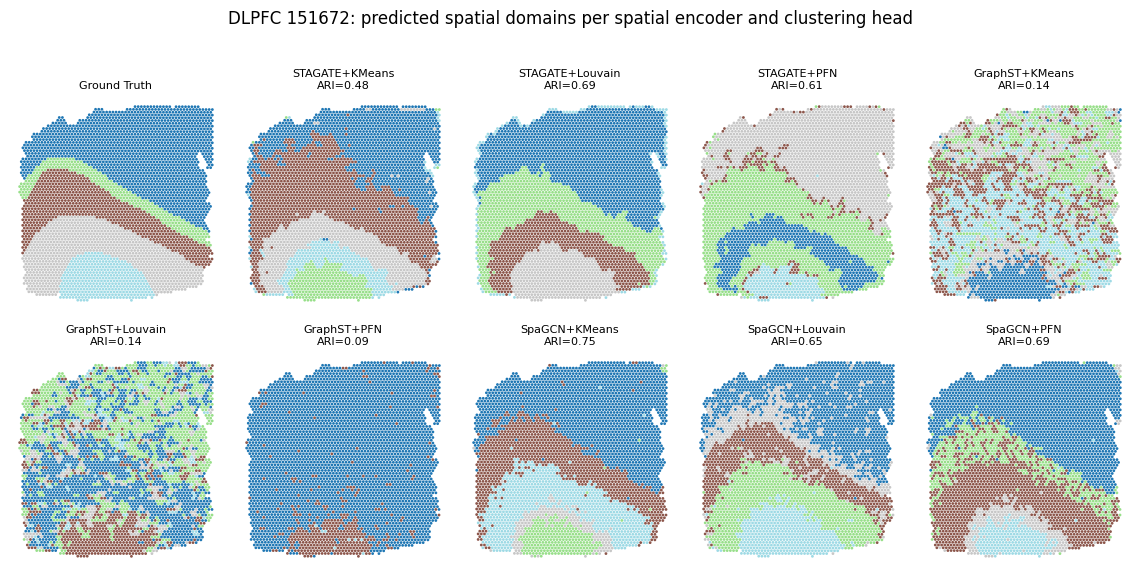

Saved -> experiment_c_plots/vis_pipeline_151672.png
Fusion...
  STAGATE+KMeans ...
  STAGATE+Louvain ...
  STAGATE+PFN ...
  SpaGCN+KMeans ...
  SpaGCN+Louvain ...
  SpaGCN+PFN ...
  Fused+KMeans ...
  Fused+Louvain ...
  Fused+PFN ...


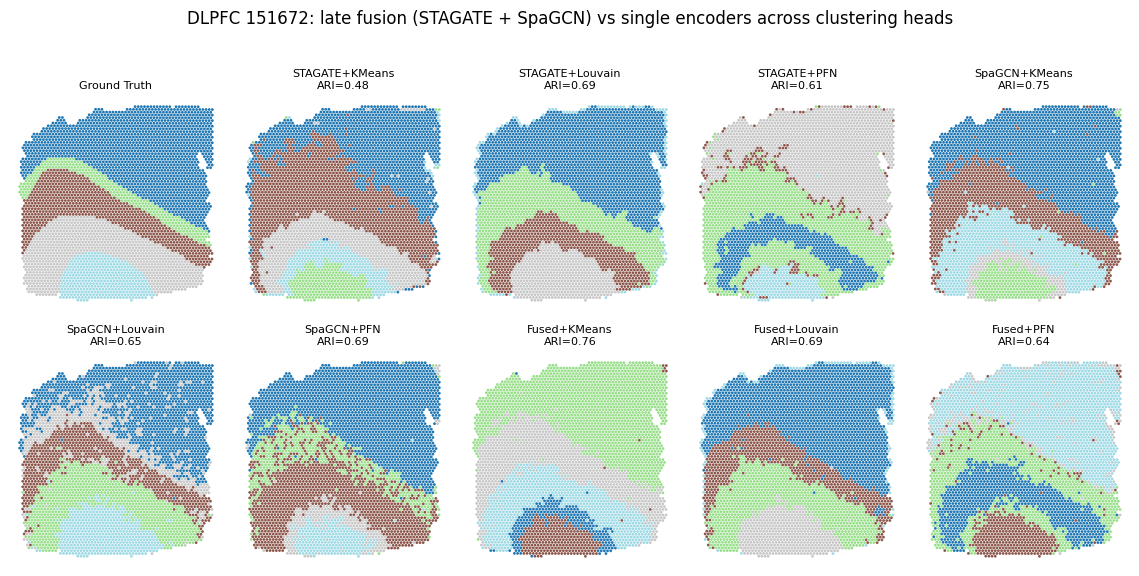

Saved -> experiment_c_plots/vis_fusion_151672.png


In [10]:
# Visualize one section: spatial clusters for every embedding x clustering-head combo.
import matplotlib.pyplot as plt

VIS_SECTION = "151672"
HEADS_VIS = ["KMeans", "Louvain", "PFN"]

if "pfn" not in globals():
    pfn = load_pfn()

adata_vis = sc.read_h5ad(f"data/DLPFC_{VIS_SECTION}_ST_final.h5ad")
coords = np.asarray(adata_vis.obsm["spatial"])
gt = adata_vis.obs["Ground Truth"].astype(str)
k = gt.nunique()
gt_codes = gt.astype("category").cat.codes.to_numpy()


def predict(emb, head):
    if head == "KMeans":
        return cluster_kmeans(emb, k)
    if head == "Louvain":
        return cluster_louvain(emb, k, max_iter=12)  # lighter search for the figure
    return run_pfn(pfn, prepare_for_pfn(emb), k)


def plot_row(reps, title, filename):
    panels = [("Ground Truth", gt_codes)]
    for name, emb in reps.items():
        for head in HEADS_VIS:
            print(f"  {name}+{head} ...", flush=True)
            pred = predict(emb, head)
            ari, _ = evaluate(gt, pred)
            panels.append((f"{name}+{head}\nARI={ari:.2f}", pred))

    ncols = 5
    nrows = int(np.ceil(len(panels) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(2.3 * ncols, 2.8 * nrows))
    axes = np.atleast_1d(axes).ravel()
    for ax, (lab, c) in zip(axes, panels):
        ax.scatter(coords[:, 0], coords[:, 1], c=c, cmap="tab20", s=4, linewidths=0)
        ax.set_title(lab, fontsize=8)
        ax.invert_yaxis()
        ax.axis("off")
    for ax in axes[len(panels):]:  # hide any unused cells
        ax.axis("off")
    fig.suptitle(title, fontsize=12, y=1.02)
    plt.tight_layout()
    fig.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved ->", filename, flush=True)


print("Embeddings pipeline...", flush=True)
pipeline_reps = {m: load_embedding(m, VIS_SECTION) for m in ["STAGATE", "GraphST", "SpaGCN"]}
plot_row(pipeline_reps,
         f"DLPFC {VIS_SECTION}: predicted spatial domains per spatial encoder and clustering head",
         f"experiment_c_plots/vis_pipeline_{VIS_SECTION}.png")

print("Fusion...", flush=True)
fusion_reps = {m: load_embedding(m, VIS_SECTION) for m in ["STAGATE", "SpaGCN"]}
fusion_reps["Fused"] = fuse([fusion_reps["STAGATE"], fusion_reps["SpaGCN"]])
plot_row(fusion_reps,
         f"DLPFC {VIS_SECTION}: late fusion (STAGATE + SpaGCN) vs single encoders across clustering heads",
         f"experiment_c_plots/vis_fusion_{VIS_SECTION}.png")

